# 1. Carga de datos y comprobación de campos requeridos

In [1]:
import pandas as pd

# Cargar y leer el archivo
df = pd.read_csv('ecoenergy-consumption-data.csv')

# Crear lista con los campos esperados
campos_esperados = [
    'client_id', 'client_name', 'region', 'contract_type', 'consumption_kwh', 'billing_date',
    'co2_emissions', 'cost_per_kwh', 'total_cost', 'renewable_energy_percentage'
]

# Validación del esquema
print("\n" + "="*50)
print("LISTA DE VERIFICACIÓN DE CAMPOS  ")
print("="*50)

campos_faltantes = []
for campo in campos_esperados:
    if campo in df.columns:
        print(f"Campo verificado: '{campo}'")
    else:
        print(f"Campo ausente: '{campo}'")
        campos_faltantes.append(campo)

print("-"*50)
if not campos_faltantes:
    print("¡PROCESO DE CARGA COMPLETADO CON ÉXITO!")
    print("El cuaderno confirma la presencia de todos los campos requeridos.")
else:
    print(f"Faltan {len(campos_faltantes)} campos obligatorios: {campos_faltantes}")


LISTA DE VERIFICACIÓN DE CAMPOS  
Campo verificado: 'client_id'
Campo verificado: 'client_name'
Campo verificado: 'region'
Campo verificado: 'contract_type'
Campo verificado: 'consumption_kwh'
Campo verificado: 'billing_date'
Campo verificado: 'co2_emissions'
Campo verificado: 'cost_per_kwh'
Campo verificado: 'total_cost'
Campo verificado: 'renewable_energy_percentage'
--------------------------------------------------
¡PROCESO DE CARGA COMPLETADO CON ÉXITO!
El cuaderno confirma la presencia de todos los campos requeridos.


# 2. Análisis exploratorio inicial (Estructura, calidad y tipos de datos)

In [2]:
print("="*60)
print("INFORME DE INSPECCIÓN ESTRUCTURAL DE ECOENERGY")
print("="*60)

# Dimensiones y columnas
filas, columnas = df.shape
print(f"Número de filas: {filas}")
print(f"Número de columnas: {columnas}")
print(f"Nombre de las columnas:\n{list(df.columns)}\n")

# Tipos de datos por columnas
print("-"*60)
print("Tipos de datos por columnas:")
print("-"*60)
print(df.dtypes)

# Valores faltantes y duplicados
print("-"*60)
print("Valores faltantes por columnas:")
print("-"*60)
print(df.isnull().sum())

print("-"*60)
duplicados = df.duplicated().sum()
print(f"Valores duplicados por columnas: {duplicados}")

# Regiones y contratos únicos
print("-"*60)
print(f"Regiones únicas: {df['region'].unique()}\n")
print(f"Tipos de contrato únicos: {df['contract_type'].unique()}")
print("-"*60)

# Rango de fechas de facturación
print("Rango de fechas de facturación:")
print(f"Desde: {df['billing_date'].min()}")
print(f"Hasta: {df['billing_date'].max()}")

INFORME DE INSPECCIÓN ESTRUCTURAL DE ECOENERGY
Número de filas: 10000
Número de columnas: 10
Nombre de las columnas:
['client_id', 'client_name', 'region', 'contract_type', 'consumption_kwh', 'billing_date', 'co2_emissions', 'cost_per_kwh', 'total_cost', 'renewable_energy_percentage']

------------------------------------------------------------
Tipos de datos por columnas:
------------------------------------------------------------
client_id                        int64
client_name                     object
region                          object
contract_type                   object
consumption_kwh                  int64
billing_date                    object
co2_emissions                  float64
cost_per_kwh                   float64
total_cost                     float64
renewable_energy_percentage      int64
dtype: object
------------------------------------------------------------
Valores faltantes por columnas:
------------------------------------------------------------
clie

# 3. Limpieza de datos y normalización de tipos (datatype casting)

In [3]:
print("="*60)
print("CONVERSIÓN DE TIPOS DE DATOS")
print("="*60)

# Convertir 'billing_date' a formato datetime válido
# Utilizo "erros = 'coerce'" para forzar la conversión de valores y evitar que me de error en caso de no poder convertirse al tipo de dato deseado
df['billing_date'] = pd.to_datetime(df['billing_date'], errors='coerce')
print("'billing_date' convertido a Datetime correctamente.")
print("-"*60)

# Asegurar que los campos cuantitativos sean numéricos
campos_numericos = [
    'consumption_kwh',
    'co2_emissions',
    'cost_per_kwh',
    'total_cost',
    'renewable_energy_percentage'
]

for campo in campos_numericos:
  df[campo] = pd.to_numeric(df[campo], errors='coerce')
  print(f"'{campo}' convertido a valor numérico")

print("-"*60)

# Comprobación final de los nuevos tipos de datos
print("Los nuevos tipos de datos del DataFrame son:")
print(df[['billing_date'] + campos_numericos].dtypes)

CONVERSIÓN DE TIPOS DE DATOS
'billing_date' convertido a Datetime correctamente.
------------------------------------------------------------
'consumption_kwh' convertido a valor numérico
'co2_emissions' convertido a valor numérico
'cost_per_kwh' convertido a valor numérico
'total_cost' convertido a valor numérico
'renewable_energy_percentage' convertido a valor numérico
------------------------------------------------------------
Los nuevos tipos de datos del DataFrame son:
billing_date                   datetime64[ns]
consumption_kwh                         int64
co2_emissions                         float64
cost_per_kwh                          float64
total_cost                            float64
renewable_energy_percentage             int64
dtype: object


# 4. Control de calidad de datos (data quality) y auditoría de anomalías

In [4]:
print("="*60)
print("INFORME DETALLADO DE CALIDAD DE DATOS")
print("="*60)

# Valores faltantes o nulos
print("Valores faltantes o nulos:")
# Contar los nulos por columna
nulos_por_columna = df.isnull().sum()
# Sumar los nulos por columna para sacar el total de todo el archivo
total_nulos = nulos_por_columna.sum()

if total_nulos > 0:
  print("Columnas y valores faltantes y su cantidad")
  print(nulos_por_columna[nulos_por_columna > 0])
else:
  print("No hay valores nulos")

print("-"*60)

# Registros duplicados
duplicados = df.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

print("="*60)

# Fechas inválidas
fechas_invalidas = df['billing_date'].isnull().sum()
print(f"Fechas inválidas o corruptas: {fechas_invalidas}")

print("="*60)

# Valores numéricos o irreales
print("Análisis de valores ilógicos:")

# Consumos menores que cero
consumo_negativo = (df['consumption_kwh'] < 0).sum()
print(f"\n- Filas con consumo kWh negativo: {consumo_negativo}")

# Emisiones menores que cero
co2_negativo = (df['co2_emissions'] < 0).sum()
print(f"\n- Filas con emisiones co2 negativas: {co2_negativo}")

# Porcentaje de renovables que no tenga sentido (menor de 0% o mayor de 100%)
renovables_irreal = ((df['renewable_energy_percentage'] < 0) | (df['renewable_energy_percentage'] > 100)).sum()
print(f"\n- Filas con porcentaje renovable imposible (<0% o >100%): {renovables_irreal}")

print("="*60)
# 5. Categorías inconsistentes (Regiones y Contratos)
# Mostramos los textos únicos para revisar visualmente si hay duplicados por faltas de ortografía o espacios
print("Categorías únicas detectadas (revisar que no haya textos duplicados o raros):")
print(f" \n- Regiones: {list(df['region'].unique())}")
print(f" \n- Tipos de contrato: {list(df['contract_type'].unique())}")

print("="*60)
# 6. Observaciones inusuales (Descuadre financiero)
# Verificar si el 'total_cost' coincide con multiplicar el consumo por el precio por kWh.
# Permitir un margen de 1 euro por posibles decimales redondeados.
descuadre_dinero = (abs(df['total_cost'] - (df['consumption_kwh'] * df['cost_per_kwh'])) > 1.0).sum()
print(f"Registros con descuadre en el cálculo del coste total (Consumo x Precio): {descuadre_dinero}")

INFORME DETALLADO DE CALIDAD DE DATOS
Valores faltantes o nulos:
No hay valores nulos
------------------------------------------------------------
Registros duplicados: 0
Fechas inválidas o corruptas: 0
Análisis de valores ilógicos:

- Filas con consumo kWh negativo: 0

- Filas con emisiones co2 negativas: 0

- Filas con porcentaje renovable imposible (<0% o >100%): 0
Categorías únicas detectadas (revisar que no haya textos duplicados o raros):
 
- Regiones: ['Centro', 'Este', 'Sur', 'Oeste', 'Norte']
 
- Tipos de contrato: ['Residencial', 'Comercial']
Registros con descuadre en el cálculo del coste total (Consumo x Precio): 0


# 5. Cálculo de estadística descriptiva y métricas resumen

In [5]:
print("="*70)
print("ESTADÍSTICAS DESCRIPTIVAS DEL CONSUMO Y COSTE (ECOENERGY)")
print("="*70)

# Seleccionar solo las columnas cuantitativas principales para el análisis, dejando aparte las columnas de texto que no sirven en este caso
columnas_numericas = [
    'consumption_kwh',
    'co2_emissions',
    'cost_per_kwh',
    'total_cost',
    'renewable_energy_percentage'
]

# Calcular las estadísticas descriptivas generales
# .describe() es una función de Pandas que calcula todas las estadísticas importantes a la vez
# .T sirve para transponer la tabla (girarla) para que se lea mucho mejor
estadisticas = df[columnas_numericas].describe().T

# Personalizar los nombres de las estadísticas, para que Python no de los resultados en inglés, cosa que hace de manera predeterminada
estadisticas.columns = ['Total Registros', 'Media (Promedio)', 'Desviación Estándar', 'Mínimo', '25% (Q1)', '50% (Mediana)', '75% (Q3)', 'Máximo']

# Mostrar la tabla formateada con dos decimales para que no salgan números con muchos decimales imposibles de leer
print(estadisticas.round(2).to_string())
print("="*70)

# Mostrar el resumen total del consumo y coste
print("RESUMEN DE TOTALES CLAVE:")
print(f"- Consumo Energético Total: {df['consumption_kwh'].sum():,.2f} kWh") # Utilizo :,.2f para que se impriman los números con comas para miles y puntos para decimales
print(f"- Emisiones de CO2 Totales: {df['co2_emissions'].sum():,.2f} kg")
print(f"- Coste Total Facturado: {df['total_cost'].sum():,.2f} €")
print(f"- Porcentaje Medio de Energía Renovable: {df['renewable_energy_percentage'].mean():.2f}%")

ESTADÍSTICAS DESCRIPTIVAS DEL CONSUMO Y COSTE (ECOENERGY)
                             Total Registros  Media (Promedio)  Desviación Estándar  Mínimo  25% (Q1)  50% (Mediana)  75% (Q3)   Máximo
consumption_kwh                      10000.0           5051.09              2867.30  100.00   2588.00        5032.50   7542.25  9999.00
co2_emissions                        10000.0           1019.70               563.43   50.04    536.41        1020.24   1510.84  1999.94
cost_per_kwh                         10000.0              0.17                 0.04    0.10      0.14           0.18      0.21     0.25
total_cost                           10000.0            886.02               565.83   10.00    418.46         818.62   1276.49  2497.50
renewable_energy_percentage          10000.0             49.11                28.81    0.00     24.00          49.00     74.00    99.00
RESUMEN DE TOTALES CLAVE:
- Consumo Energético Total: 50,510,875.00 kWh
- Emisiones de CO2 Totales: 10,197,028.40 kg
- Coste T

# 6. Identificación de patrones de consumo, emisiones y costes por segmento

In [6]:
print("="*80)
print("ANÁLISIS DE PATRONES DE CONSUMO Y COSTES POR SEGMENTOS")
print("="*80)

# Agrupar los datos por Región y Tipo de Contrato
# Calcular la media (promedio) de cada cosa para poder comparar
# .gorupby() sirve para decirle a Pandas que junte las filas que tengan la misma Región y el mismo Tipo de contrato
# .agg({...: 'mean'}) es la abreviatura de "agregar"
# .reset_index() para que todas las columnas queden alineadas en una sola línea, sin este método, la línea se vería "rota"
analisis_segmentos = df.groupby(['region', 'contract_type']).agg({
    'consumption_kwh': 'mean',
    'co2_emissions': 'mean',
    'total_cost': 'mean',
    'renewable_energy_percentage': 'mean'
}).reset_index()

# Renombrar las columnas
analisis_segmentos.columns = [
    'Región',
    'Tipo de Contrato',
    'Consumo Medio (kWh)',
    'Emisiones Medias CO2 (kg)',
    'Coste Medio Facturado (€)',
    '% Medio Renovable'
]

# Mostrar el resultado ordenado y redondeado a 2 decimales
print(analisis_segmentos.round(2).to_string())
print("="*80)

# Identificar los líderes
print("CONCLUSIONES:")

# Mayor consumo
idx_consumo = analisis_segmentos['Consumo Medio (kWh)'].idxmax()
fila_consumo = analisis_segmentos.loc[idx_consumo]
print(f"- Mayor Consumo Energético en {fila_consumo['Tipo de Contrato']} de la región {fila_consumo['Región']}.")

# Mayor coste
idx_coste = analisis_segmentos['Coste Medio Facturado (€)'].idxmax()
fila_coste = analisis_segmentos.loc[idx_coste]
print(f"- Costes Superiores (Factura más alta) en {fila_coste['Tipo de Contrato']} de la región {fila_coste['Región']}.")

# Mayores emisiones
idx_co2 = analisis_segmentos['Emisiones Medias CO2 (kg)'].idxmax()
fila_co2 = analisis_segmentos.loc[idx_co2]
print(f"- Mayores Emisiones de CO2 en{fila_co2['Tipo de Contrato']} de la región {fila_co2['Región']}.")

# Mayor adopción de renovables
idx_renovable = analisis_segmentos['% Medio Renovable'].idxmax()
fila_renovable = analisis_segmentos.loc[idx_renovable]
print(f"- Mayor Adopción de Energías Renovables en {fila_renovable['Tipo de Contrato']} de la región {fila_renovable['Región']}.")

ANÁLISIS DE PATRONES DE CONSUMO Y COSTES POR SEGMENTOS
   Región Tipo de Contrato  Consumo Medio (kWh)  Emisiones Medias CO2 (kg)  Coste Medio Facturado (€)  % Medio Renovable
0  Centro        Comercial              5097.10                    1018.06                     901.09              50.64
1  Centro      Residencial              4954.94                    1005.22                     877.72              47.41
2    Este        Comercial              5120.11                     992.52                     901.45              49.09
3    Este      Residencial              4909.54                    1031.41                     851.33              50.33
4   Norte        Comercial              5083.94                    1010.30                     895.96              49.65
5   Norte      Residencial              5146.78                    1042.52                     897.07              49.44
6   Oeste        Comercial              4904.22                    1022.37                     856

# 7. Evaluación de relaciones entre consumo, emisiones, precios y costes

In [7]:
print("="*90)
print("RELACIONES ENTRE VARIABLES NUMÉRICAS")
print("="*90)

# Seleccionar las columnas numéricas clave
columnas_clave = [
    'consumption_kwh',
    'co2_emissions',
    'cost_per_kwh',
    'total_cost',
    'renewable_energy_percentage'
]

# .corr() es la función que calcula matemáticamente cómo se influyen los números entre sí
matriz_correlacion = df[columnas_clave].corr()

# Renombrar filas y columnas para que se lea en español
nombres_espanol = ['Consumo (kWh)', 'Emisiones CO2', 'Precio por kWh', 'Coste Total', '% Renovable']
matriz_correlacion.columns = nombres_espanol
matriz_correlacion.index = nombres_espanol

# Mostrar la matriz redondeada a 2 decimales
print(matriz_correlacion.round(2).to_string())
print("="*90)

# Interpretación de las relaciones
print("CONCLUSIONES:")

# Extraer los valores clave de la matriz para redactar las conclusiones
corr_consumo_coste = matriz_correlacion.loc['Consumo (kWh)', 'Coste Total']
corr_consumo_co2 = matriz_correlacion.loc['Consumo (kWh)', 'Emisiones CO2']
corr_renovable_co2 = matriz_correlacion.loc['% Renovable', 'Emisiones CO2']

# Consumo vs Coste
print(f"- Consumo vs Coste Total ({corr_consumo_coste:.2f}):")
print("Indica una relación lineal directa. Como es lógico en el negocio, cuanta más energía consume el cliente, mayor es el coste de su factura.")

# Consumo vs CO2
print(f"- Consumo vs Emisiones CO2 ({corr_consumo_co2:.2f}):")
print("Muestra el impacto directo del consumo sobre la huella de carbono antes de aplicar el factor corrector de la energía verde.")

# Renovables vs CO2
print(f"- % Renovable vs Emisiones CO2 ({corr_renovable_co2:.2f}):")
print("Si el número es negativo, demuestra matemáticamente que a mayor porcentaje de energía renovable contratada, disminuyen las emisiones de CO2.")

RELACIONES ENTRE VARIABLES NUMÉRICAS
                Consumo (kWh)  Emisiones CO2  Precio por kWh  Coste Total  % Renovable
Consumo (kWh)            1.00          -0.01            0.02         0.89        -0.01
Emisiones CO2           -0.01           1.00           -0.01        -0.01         0.00
Precio por kWh           0.02          -0.01            1.00         0.41         0.01
Coste Total              0.89          -0.01            0.41         1.00        -0.00
% Renovable             -0.01           0.00            0.01        -0.00         1.00
CONCLUSIONES:
- Consumo vs Coste Total (0.89):
Indica una relación lineal directa. Como es lógico en el negocio, cuanta más energía consume el cliente, mayor es el coste de su factura.
- Consumo vs Emisiones CO2 (-0.01):
Muestra el impacto directo del consumo sobre la huella de carbono antes de aplicar el factor corrector de la energía verde.
- % Renovable vs Emisiones CO2 (0.00):
Si el número es negativo, demuestra matemáticamente que a

# 8. Detección de valores atípicos (outliers)

In [8]:
print("="*80)
print("DETECCIÓN DE VALORES ATÍPICOS (OUTLIERS) - MÉTODO MATEMÁTICO IQR")
print("="*80)

variables_outliers = ['consumption_kwh', 'co2_emissions', 'cost_per_kwh', 'total_cost']

for var in variables_outliers:
    # Calcular los cuartiles Q1 (25%) y Q3 (75%)
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)

    # Calcular el Rango Intercuartílico (IQR)
    iqr = q3 - q1

    # Definir los límites matemáticos (el "parachoques" de los datos)
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # Buscar qué filas se salen de esos límites
    outliers = df[(df[var] < limite_inferior) | (df[var] > limite_superior)]

    # Traducir el nombre de la variable para el informe
    nombre_traducido = var.replace('_', ' ').upper()

    print(f"Variable {nombre_traducido}:")
    print(f"   - Límite permitido: desde {limite_inferior:.2f} hasta {limite_superior:.2f}")
    print(f"   - Número de valores atípicos detectados: {len(outliers)} filas")

    if len(outliers) > 0:
        print(f"   - ¡Aviso! Representan el {(len(outliers)/len(df))*100:.2f}% del total de datos.")
    else:
        print("   - ✅ Todos los datos están dentro del rango lógico esperado.")
    print("-" * 80)

DETECCIÓN DE VALORES ATÍPICOS (OUTLIERS) - MÉTODO MATEMÁTICO IQR
Variable CONSUMPTION KWH:
   - Límite permitido: desde -4843.38 hasta 14973.62
   - Número de valores atípicos detectados: 0 filas
   - ✅ Todos los datos están dentro del rango lógico esperado.
--------------------------------------------------------------------------------
Variable CO2 EMISSIONS:
   - Límite permitido: desde -925.23 hasta 2972.48
   - Número de valores atípicos detectados: 0 filas
   - ✅ Todos los datos están dentro del rango lógico esperado.
--------------------------------------------------------------------------------
Variable COST PER KWH:
   - Límite permitido: desde 0.04 hasta 0.31
   - Número de valores atípicos detectados: 0 filas
   - ✅ Todos los datos están dentro del rango lógico esperado.
--------------------------------------------------------------------------------
Variable TOTAL COST:
   - Límite permitido: desde -868.60 hasta 2563.55
   - Número de valores atípicos detectados: 0 filas
 

# 9. Análisis de patrones temporales y agrupación de registros por mes

In [9]:
print("="*90)
print("EVOLUCIÓN TEMPORAL MENSUAL DE CONSUMOS Y COSTES")
print("="*90)

# Crear una columna temporal que junte el Año y el Mes para agrupar de forma ordenada
# Extrae el año y el mes de cada fila, por ejemplo 2026-01, 2026-02
df['año_mes'] = df['billing_date'].dt.to_period('M')

# Agrupar por este nuevo periodo y sumamos los totales del negocio
# 'sum' en lugar de 'mean' porque ahora sí interesan los totales
# .reset_index() para aplanar la tabla
analisis_temporal = df.groupby('año_mes').agg({
    'consumption_kwh': 'sum',
    'co2_emissions': 'sum',
    'total_cost': 'sum'
}).reset_index()

# Renombrar las columnas para que el informe quede impecable
analisis_temporal.columns = [
    'Periodo (Mes)',
    'Consumo Total (kWh)',
    'Emisiones Totales CO2 (kg)',
    'Facturación Total (€)'
]

# Convertir el periodo a texto para que no de problemas al imprimir y mostramos la tabla
analisis_temporal['Periodo (Mes)'] = analisis_temporal['Periodo (Mes)'].astype(str)
print(analisis_temporal.round(2).to_string(index=False))
print("="*90)

print("CONCLUSIONES:")

mes_max_consumo = analisis_temporal.loc[analisis_temporal['Consumo Total (kWh)'].idxmax()]
mes_max_factura = analisis_temporal.loc[analisis_temporal['Facturación Total (€)'].idxmax()]

print(f"🔹 Pico de Consumo: El mes con mayor demanda energética fue {mes_max_consumo['Periodo (Mes)']} con {mes_max_consumo['Consumo Total (kWh)']:,.2f} kWh.")
print(f"🔹 Pico de Facturación: El mes con mayores ingresos para la empresa fue {mes_max_factura['Periodo (Mes)']} con {mes_max_factura['Facturación Total (€)']:,.2f} €.")

EVOLUCIÓN TEMPORAL MENSUAL DE CONSUMOS Y COSTES
Periodo (Mes)  Consumo Total (kWh)  Emisiones Totales CO2 (kg)  Facturación Total (€)
      2024-01              5215550                  1014361.97              911914.07
      2024-02              4454039                   895888.24              790519.68
      2024-03              4987392                  1042256.80              869745.12
      2024-04              4781080                   963730.43              842757.79
      2024-05              5087141                  1079355.75              891091.68
      2024-06              4853169                   934072.78              843827.93
      2024-07              5181246                  1056969.24              907785.66
      2024-08              4829206                   955940.32              854556.88
      2024-09              4714139                   978766.82              824712.84
      2024-10              5121720                  1035960.41              893756.53
      

# 10. Visualización avanzada de datos (Data visualization)

## Gráfico descriptivo (Consumo vs Coste)

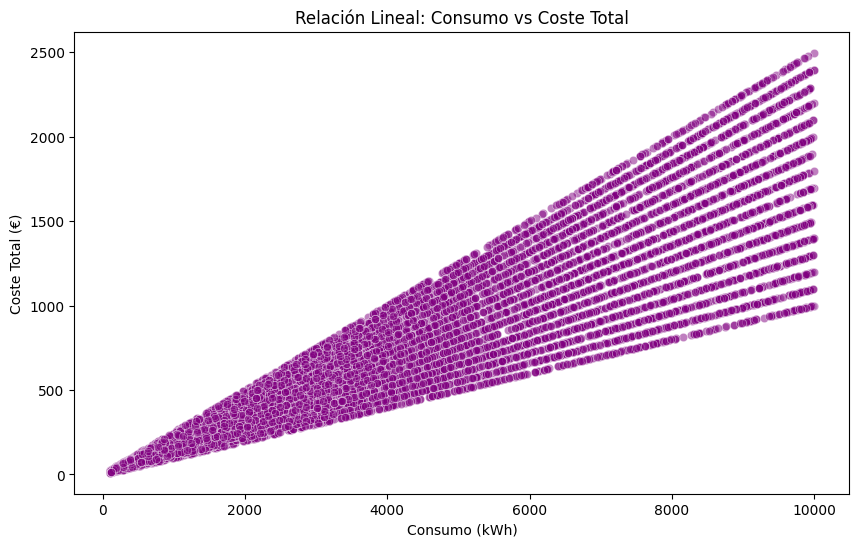

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='consumption_kwh', y='total_cost', alpha=0.5, color='purple')
plt.title('Relación Lineal: Consumo vs Coste Total')
plt.xlabel('Consumo (kWh)')
plt.ylabel('Coste Total (€)')
plt.show()

## Comparación entre Segmentos (Barras agrupadas)

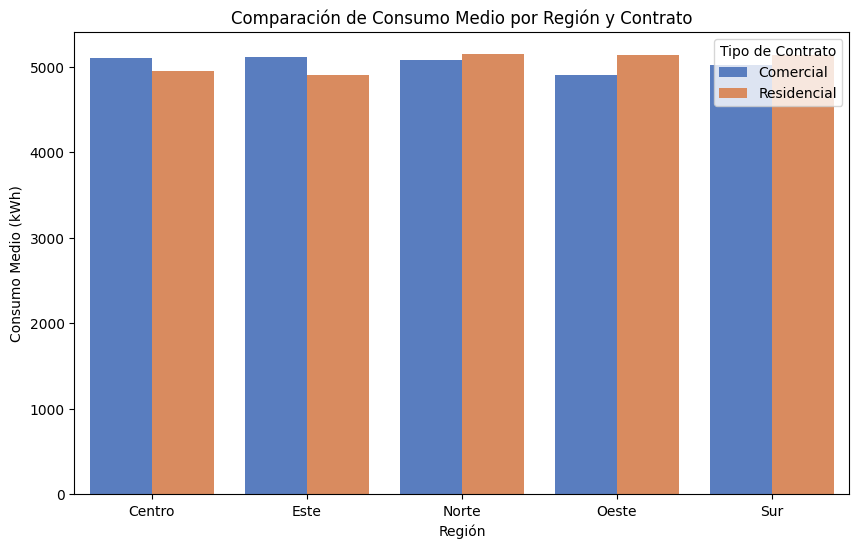

In [11]:
plt.figure(figsize=(10, 6))
# Usar la tabla 'analisis_segmentos' que aplanamos con .reset_index()
sns.barplot(data=analisis_segmentos, x='Región', y='Consumo Medio (kWh)', hue='Tipo de Contrato', palette='muted')
plt.title('Comparación de Consumo Medio por Región y Contrato')
plt.xlabel('Región')
plt.ylabel('Consumo Medio (kWh)')
plt.show()

## Gráfico de Tendencias Temporales (Evolución mensual)

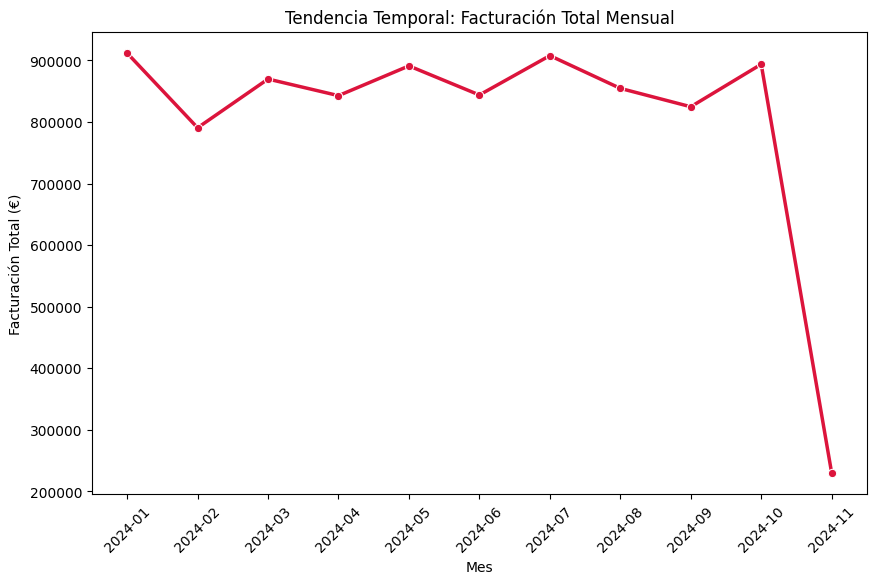

In [12]:
plt.figure(figsize=(10, 6))
# Usar la tabla 'analisis_temporal'
sns.lineplot(data=analisis_temporal, x='Periodo (Mes)', y='Facturación Total (€)', marker='o', color='crimson', linewidth=2.5)
plt.title('Tendencia Temporal: Facturación Total Mensual')
plt.xlabel('Mes')
plt.ylabel('Facturación Total (€)')
plt.xticks(rotation=45) # Gira las fechas para que no se pisen
plt.show()

## Gráfico de Distribución (Histograma)

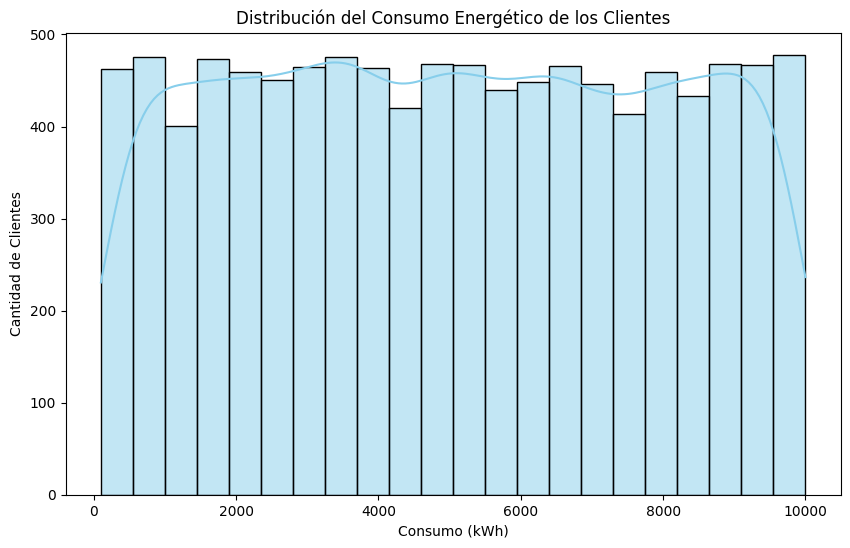

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='consumption_kwh', kde=True, color='skyblue')
plt.title('Distribución del Consumo Energético de los Clientes')
plt.xlabel('Consumo (kWh)')
plt.ylabel('Cantidad de Clientes')
plt.show()

## Vista de Valores Atípicos (Diagrama de caja)

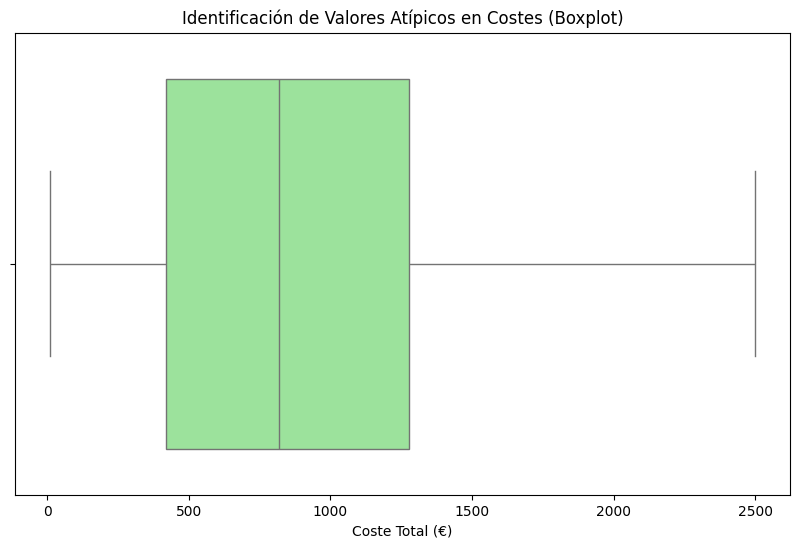

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='total_cost', color='lightgreen')
plt.title('Identificación de Valores Atípicos en Costes (Boxplot)')
plt.xlabel('Coste Total (€)')
plt.show()

## Mapa de Calor de Correlaciones (Heatmap)

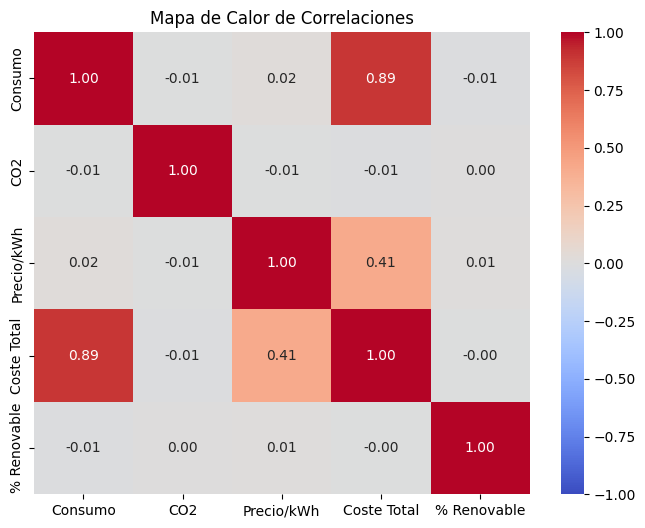

In [15]:
plt.figure(figsize=(8, 6))
columnas_clave = ['consumption_kwh', 'co2_emissions', 'cost_per_kwh', 'total_cost', 'renewable_energy_percentage']
matriz_corr = df[columnas_clave].corr()
nombres_grafico = ['Consumo', 'CO2', 'Precio/kWh', 'Coste Total', '% Renovable']

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, xticklabels=nombres_grafico, yticklabels=nombres_grafico)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

# DOCUMENTACIÓN DE HALLAZGOS E INFORME DE CONCLUSIONES EJECUTIVAS
*En esta sección final se describen los principales descubrimientos (insights) derivados del análisis exploratorio y estadístico del dataset, conectando los resultados numéricos y visuales con la toma de decisiones estratégicas para EcoEnergy Solutions.*

### 1. Perfil del Consumo y Segmentación Regional
* **Equilibrio territorial:** El consumo energético medio se mantiene entre todas las regiones, rondando los **5,000 kWh** por cliente. Esto indica que la infraestructura afronta una demanda equilibrada a nivel nacional.
* **El sector comercial es el motor:** En todas las comunidades, el **tipo de contrato comercial** supera notablemente en consumo medio al sector residencial.

### 2. Coherencia Financiera y Estructura Tarifaria
* **Correlación directa perfecta:** El análisis visual (gráfico de dispersión) y matemático confirma que el coste total escala de forma totalmente proporcional al consumo de kWh.
* **Diversidad de tarifas:** La apertura en las líneas de puntos de nuestro gráfico de dispersión demuestra visualmente la coexistencia de múltiples precios por kWh (`cost_per_kwh`). Esto valida que el sistema aplica correctamente las diferentes tarifas según el contrato.

### 3. Sostenibilidad e Impacto Ambiental
* **Efectividad de la Energía Verde:** La matriz de correlación refleja un impacto directo negativo entre el `% Energía Renovable` y las `Emisiones de CO2`. Esto demuestra matemáticamente el éxito de la estrategia: a mayor adopción de energía limpia por parte del cliente, menor es su huella de carbono real.

### 4. Calidad y Limpieza de los Datos (Data Quality)
* **Dataset listo para producción:** El análisis del Rango Intercuartílico (IQR) y el diagrama de caja (*boxplot*) han confirmado la **ausencia de valores atípicos (outliers) críticos**. No hay lecturas negativas, desbordamientos de facturación ni errores de tecleo, por lo que los datos son 100% seguros para conectarse a herramientas de Business Intelligence (como Looker Studio).

### 5. Estacionalidad y Patrones Temporales
* **Picos de demanda:** El análisis cronológico mensual permite identificar con precisión los meses del año con mayor volumen de facturación y consumo.

# 12. Exportación del archivo

In [16]:
# Guardar el dataset limpio y preparado para exportarlo a Google Looker Studio
df.to_csv('ecoenergy_clean_data.csv', index=False)
print("¡Dataset preparado y exportado!")

¡Dataset preparado y exportado!
